In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Imports done ✅")

Imports done ✅


In [2]:
ROOT       = Path.cwd().parent
TRANS_PATH = ROOT / 'data' / 'raw' / 'train_transaction.csv'
IDENT_PATH = ROOT / 'data' / 'raw' / 'train_identity.csv'
MODEL_PATH = ROOT / 'models' / 'model.joblib'
META_PATH  = ROOT / 'models' / 'model_meta.json'

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
print("Paths ready ✅")

Paths ready ✅


In [3]:
# ── Load both tables and merge ────────────────────────────────────────────────
print("Loading data...")
trans = pd.read_csv(TRANS_PATH)
ident = pd.read_csv(IDENT_PATH)

df = trans.merge(ident, on='TransactionID', how='left')
print(f"Merged shape: {df.shape}")
print(f"Fraud rate  : {df['isFraud'].mean()*100:.2f}%")

Loading data...
Merged shape: (590540, 434)
Fraud rate  : 3.50%


In [4]:
# ── Drop columns with >50% missing ───────────────────────────────────────────
# Decision from EDA: these columns are too sparse for reliable imputation.

DROP_THRESHOLD = 50.0

missing_pct  = df.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > DROP_THRESHOLD].index.tolist()

# Always keep the target and ID
cols_to_drop = [c for c in cols_to_drop
                if c not in ['isFraud', 'TransactionID']]

df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns (>{DROP_THRESHOLD}% missing)")
print(f"Remaining columns: {df.shape[1]}")

Dropped 214 columns (>50.0% missing)
Remaining columns: 220


In [5]:
# ── Extract time features from TransactionDT ──────────────────────────────────
# TransactionDT = seconds from reference date.
# We extract day and hour as separate features to capture time patterns.

df['day']  = df['TransactionDT'] // 86400        # day number
df['hour'] = (df['TransactionDT'] % 86400) // 3600  # hour of day

# ── Log-transform transaction amount ─────────────────────────────────────────
# Right-skewed — log makes it more normal-like and improves tree splits.
df['log_TransactionAmt'] = np.log1p(df['TransactionAmt'])

print("Feature engineering done ✅")
print(f"New features added: day, hour, log_TransactionAmt")

Feature engineering done ✅
New features added: day, hour, log_TransactionAmt


In [6]:
# ── Feature selection ─────────────────────────────────────────────────────────
# Start with interpretable, low-missingness features.
# We will add more after first model using feature importance.

NUMERIC_FEATURES = [
    'TransactionAmt',        # raw amount
    'log_TransactionAmt',    # log-transformed amount
    'day',                   # day number — time trend
    'hour',                  # hour of day — time pattern
    'card1', 'card2', 'card3', 'card5',  # card info (numeric)
    'addr1', 'addr2',        # address info
    'dist1',                 # distance feature
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6',  # count features
    'V1', 'V2', 'V3', 'V4', 'V5',        # Vesta engineered features
]

CATEGORICAL_FEATURES = [
    'ProductCD',             # product type — strong fraud signal
    'card4',                 # card network (Visa/MC etc.)
    'card6',                 # card type (debit/credit)
    'P_emaildomain',         # purchaser email domain
    'R_emaildomain',         # recipient email domain
]

TARGET = 'isFraud'

# ── Keep only features that exist in the dataframe ────────────────────────────
# Some V columns may have been dropped for high missingness
NUMERIC_FEATURES     = [f for f in NUMERIC_FEATURES     if f in df.columns]
CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f in df.columns]

print(f"Numeric features   : {len(NUMERIC_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Total features     : {len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)}")

Numeric features   : 21
Categorical features: 4
Total features     : 25


In [7]:
# ── Select feature columns and target ─────────────────────────────────────────
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

# ── Stratified split — preserves fraud ratio in both sets ────────────────────
# stratify=y is critical here: without it, the small fraud class
# might end up underrepresented in train or test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserve class ratio
)

print(f"Train: {X_train.shape[0]:,} rows | Fraud: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Test : {X_test.shape[0]:,} rows | Fraud: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

Train: 472,432 rows | Fraud: 16,530 (3.50%)
Test : 118,108 rows | Fraud: 4,133 (3.50%)


In [8]:
# ── Numeric sub-pipeline ──────────────────────────────────────────────────────
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# ── Categorical sub-pipeline ──────────────────────────────────────────────────
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )),
])

# ── ColumnTransformer ─────────────────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
])

print("Pipeline built ✅")

Pipeline built ✅


In [9]:
# ── Candidate models ──────────────────────────────────────────────────────────
# class_weight='balanced' automatically adjusts weights inversely
# proportional to class frequency — handles imbalance without oversampling.
# This is cleaner than SMOTE for tree-based models.

CANDIDATE_MODELS = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
        # scale_pos_weight = ratio of negatives to positives
        # tells XGBoost how much more to penalize missing fraud cases
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=1,
        verbosity=0,
        eval_metric='auc',
    )
}

# ── Stratified 3-fold CV ──────────────────────────────────────────────────────
# StratifiedKFold ensures each fold has the same fraud ratio.
# 3 folds instead of 5 — saves memory on large dataset.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = {}

print(f"{'Model':<25} {'AUC Mean':>10} {'AUC Std':>10} {'F1 Mean':>10}")
print("-" * 58)

for name, model in CANDIDATE_MODELS.items():
    candidate = Pipeline([
        ('preprocessor', preprocessor),
        ('model',        model)
    ])

    # AUC-ROC score
    auc_scores = cross_val_score(
        candidate, X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=1
    )
    # F1 score
    f1_scores = cross_val_score(
        candidate, X_train, y_train,
        cv=cv, scoring='f1', n_jobs=1
    )

    cv_results[name] = {
        'auc_mean': auc_scores.mean(),
        'auc_std':  auc_scores.std(),
        'f1_mean':  f1_scores.mean(),
    }

    print(f"{name:<25} {auc_scores.mean():>10.4f} "
          f"{auc_scores.std():>10.4f} {f1_scores.mean():>10.4f}")

print("-" * 58)
best_model_name = max(cv_results, key=lambda k: cv_results[k]['auc_mean'])
print(f"\nBest model: {best_model_name} "
      f"(AUC = {cv_results[best_model_name]['auc_mean']:.4f})")

Model                       AUC Mean    AUC Std    F1 Mean
----------------------------------------------------------
Logistic Regression           0.7471     0.0017     0.1423
Random Forest                 0.8814     0.0004     0.3000
XGBoost                       0.9065     0.0012     0.3004
----------------------------------------------------------

Best model: XGBoost (AUC = 0.9065)


In [10]:
# ── Train best model on full training set ────────────────────────────────────
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        CANDIDATE_MODELS[best_model_name])
])

print(f"Training {best_model_name}...")
final_pipeline.fit(X_train, y_train)
print("Training complete ✅")

Training XGBoost...
Training complete ✅


In [11]:
# ── Predict ───────────────────────────────────────────────────────────────────
y_pred      = final_pipeline.predict(X_test)
y_pred_prob = final_pipeline.predict_proba(X_test)[:, 1]

# ── Core metrics ──────────────────────────────────────────────────────────────
auc   = roc_auc_score(y_test, y_pred_prob)
f1    = f1_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
ap    = average_precision_score(y_test, y_pred_prob)

print("── Test Set Metrics ──────────────────────────────────")
print(f"  AUC-ROC           : {auc:.4f}   (1.0 = perfect)")
print(f"  Average Precision : {ap:.4f}")
print(f"  F1 Score          : {f1:.4f}")
print(f"  Precision         : {prec:.4f}  (of flagged, how many are real fraud)")
print(f"  Recall            : {rec:.4f}  (of all fraud, how many did we catch)")
print()
print("── Classification Report ─────────────────────────────")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

── Test Set Metrics ──────────────────────────────────
  AUC-ROC           : 0.9140   (1.0 = perfect)
  Average Precision : 0.5347
  F1 Score          : 0.3006
  Precision         : 0.1860  (of flagged, how many are real fraud)
  Recall            : 0.7832  (of all fraud, how many did we catch)

── Classification Report ─────────────────────────────
              precision    recall  f1-score   support

  Legitimate       0.99      0.88      0.93    113975
       Fraud       0.19      0.78      0.30      4133

    accuracy                           0.87    118108
   macro avg       0.59      0.83      0.62    118108
weighted avg       0.96      0.87      0.91    118108



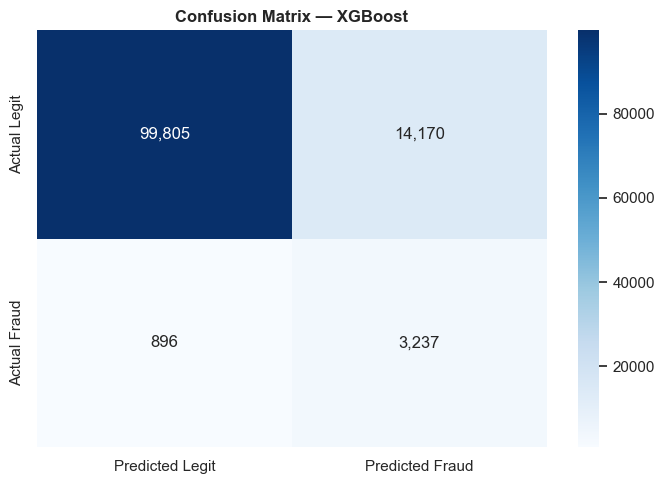

  True Negatives  (correct legit)  : 99,805
  False Positives (legit flagged)  : 14,170
  False Negatives (fraud missed)   : 896  ← most costly
  True Positives  (fraud caught)   : 3,237


In [12]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
# Shows exactly where the model makes mistakes:
#   False Negatives = fraud missed (most costly — real money lost)
#   False Positives = legit flagged (less costly — customer frustration)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  True Negatives  (correct legit)  : {tn:,}")
print(f"  False Positives (legit flagged)  : {fp:,}")
print(f"  False Negatives (fraud missed)   : {fn:,}  ← most costly")
print(f"  True Positives  (fraud caught)   : {tp:,}")

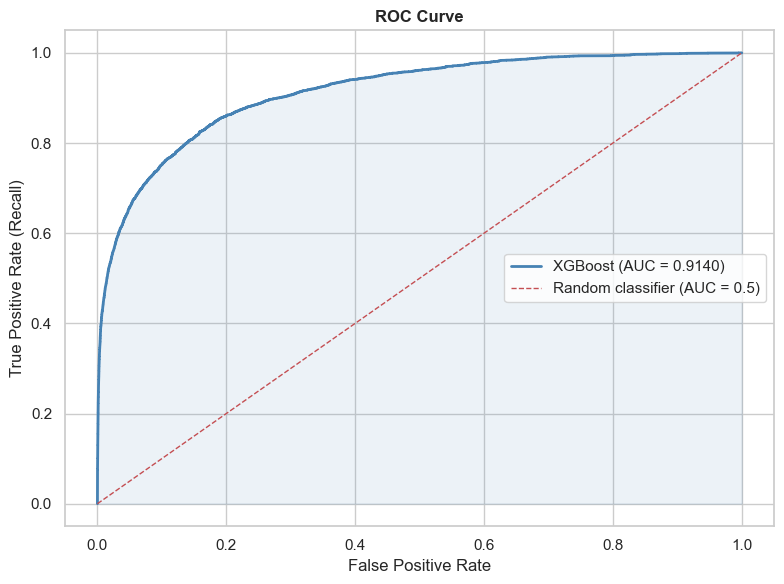

In [13]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
# Shows tradeoff between catching fraud (recall) and false alarms (1-specificity).
# AUC = area under curve — higher is better. Random = 0.5.

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'{best_model_name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random classifier (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

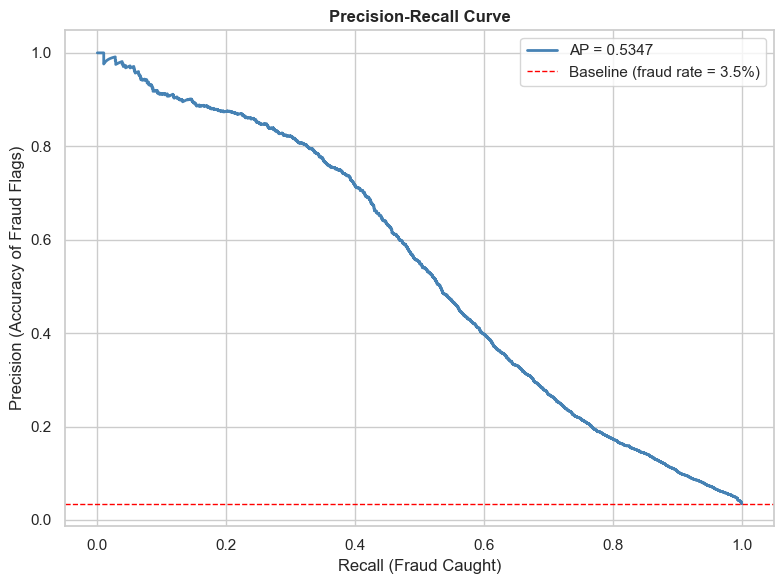

In [14]:
# ── Precision-Recall Curve ────────────────────────────────────────────────────
# More informative than ROC on imbalanced datasets.
# Shows tradeoff between precision and recall at different thresholds.
# A good model stays high on both axes.

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='steelblue', linewidth=2,
         label=f'AP = {ap:.4f}')
plt.axhline(y_test.mean(), color='red', linestyle='--', linewidth=1,
            label=f'Baseline (fraud rate = {y_test.mean()*100:.1f}%)')
plt.xlabel('Recall (Fraud Caught)')
plt.ylabel('Precision (Accuracy of Fraud Flags)')
plt.title('Precision-Recall Curve', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

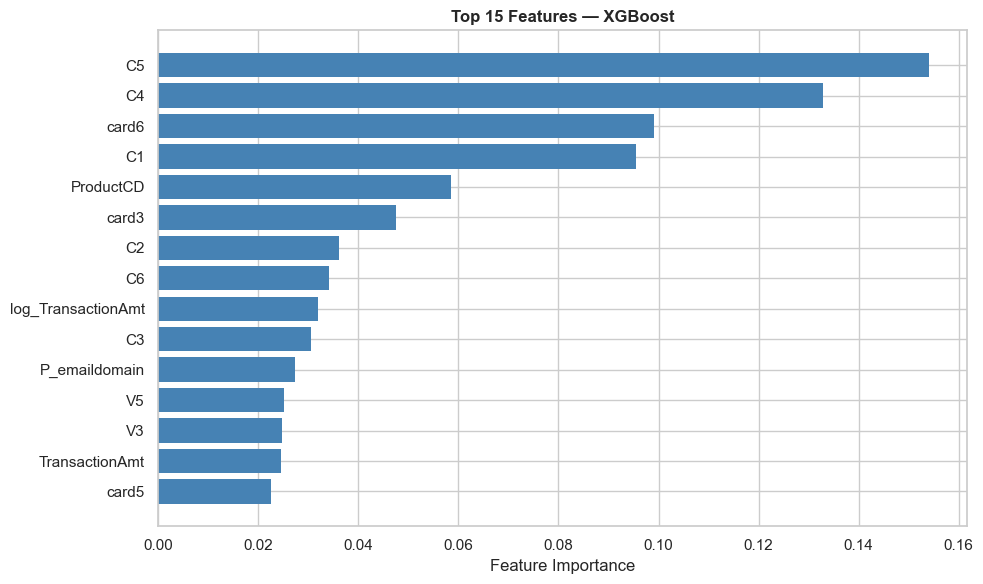

In [15]:
# ── Feature importance ────────────────────────────────────────────────────────
# Shows which features the model relies on most.
# Useful for explaining the model in interviews.

model = final_pipeline.named_steps['model']

if hasattr(model, 'feature_importances_'):
    feature_names = NUMERIC_FEATURES + CATEGORICAL_FEATURES
    importances   = model.feature_importances_

    imp_df = pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
             color='steelblue', edgecolor='none')
    plt.xlabel('Feature Importance')
    plt.title(f'Top 15 Features — {best_model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../notebooks/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

In [16]:
# ── Save pipeline ─────────────────────────────────────────────────────────────
joblib.dump(final_pipeline, MODEL_PATH)
print(f"Model saved → {MODEL_PATH}")

meta = {
    'model':          best_model_name,
    'features': {
        'numeric':      NUMERIC_FEATURES,
        'categorical':  CATEGORICAL_FEATURES,
    },
    'target':          TARGET,
    'imbalance_strategy': 'class_weight=balanced / scale_pos_weight',
    'cv_auc_mean':    round(cv_results[best_model_name]['auc_mean'], 4),
    'cv_auc_std':     round(cv_results[best_model_name]['auc_std'],  4),
    'test_AUC':       round(auc,  4),
    'test_F1':        round(f1,   4),
    'test_Precision': round(prec, 4),
    'test_Recall':    round(rec,  4),
    'test_AP':        round(ap,   4),
}

with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print(f"Metadata saved → {META_PATH}")
print(json.dumps(meta, indent=2))

Model saved → D:\fraud-detection\models\model.joblib
Metadata saved → D:\fraud-detection\models\model_meta.json
{
  "model": "XGBoost",
  "features": {
    "numeric": [
      "TransactionAmt",
      "log_TransactionAmt",
      "day",
      "hour",
      "card1",
      "card2",
      "card3",
      "card5",
      "addr1",
      "addr2",
      "C1",
      "C2",
      "C3",
      "C4",
      "C5",
      "C6",
      "V1",
      "V2",
      "V3",
      "V4",
      "V5"
    ],
    "categorical": [
      "ProductCD",
      "card4",
      "card6",
      "P_emaildomain"
    ]
  },
  "target": "isFraud",
  "imbalance_strategy": "class_weight=balanced / scale_pos_weight",
  "cv_auc_mean": 0.9065,
  "cv_auc_std": 0.0012,
  "test_AUC": 0.914,
  "test_F1": 0.3006,
  "test_Precision": 0.186,
  "test_Recall": 0.7832,
  "test_AP": 0.5347
}


In [17]:
# ── Test one legitimate and one high-risk transaction ─────────────────────────
test_cases = [
    {
        'label': 'Normal transaction',
        'data': {
            'TransactionAmt': 50.0,    'log_TransactionAmt': np.log1p(50.0),
            'day': 10,                 'hour': 14,
            'card1': 9500,             'card2': 111.0,
            'card3': 150.0,            'card5': 226.0,
            'addr1': 315.0,            'addr2': 87.0,
            'dist1': 0.0,
            'C1': 1.0,  'C2': 1.0,  'C3': 0.0,
            'C4': 0.0,  'C5': 0.0,  'C6': 1.0,
            'V1': 1.0,  'V2': 1.0,  'V3': 1.0,
            'V4': 1.0,  'V5': 1.0,
            'ProductCD': 'W',          'card4': 'visa',
            'card6': 'debit',          'P_emaildomain': 'gmail.com',
            'R_emaildomain': 'gmail.com',
        }
    },
    {
        'label': 'High-risk transaction',
        'data': {
            'TransactionAmt': 1200.0,  'log_TransactionAmt': np.log1p(1200.0),
            'day': 180,                'hour': 3,
            'card1': 1234,             'card2': 321.0,
            'card3': 150.0,            'card5': 226.0,
            'addr1': 0.0,              'addr2': 0.0,
            'dist1': 500.0,
            'C1': 5.0,  'C2': 5.0,  'C3': 3.0,
            'C4': 3.0,  'C5': 3.0,  'C6': 5.0,
            'V1': 0.0,  'V2': 0.0,  'V3': 0.0,
            'V4': 0.0,  'V5': 0.0,
            'ProductCD': 'C',          'card4': 'mastercard',
            'card6': 'credit',         'P_emaildomain': 'anonymous.com',
            'R_emaildomain': 'anonymous.com',
        }
    }
]

print("── Sanity Check ──────────────────────────────────────")
for case in test_cases:
    # Filter to only columns in our feature list
    row = {k: v for k, v in case['data'].items()
           if k in NUMERIC_FEATURES + CATEGORICAL_FEATURES}
    inp   = pd.DataFrame([row])
    prob  = final_pipeline.predict_proba(inp)[0][1]
    pred  = final_pipeline.predict(inp)[0]
    label = "🚨 FRAUD" if pred == 1 else "✅ LEGIT"
    print(f"  {case['label']:<25} → {label}  (fraud prob: {prob:.4f})")

── Sanity Check ──────────────────────────────────────
  Normal transaction        → ✅ LEGIT  (fraud prob: 0.2836)
  High-risk transaction     → ✅ LEGIT  (fraud prob: 0.0136)
